# D_S1 — Dense SNR Scatterplot Generation (Comparison Plot)

Generates scatterplots with **dense SNR sampling** (200 levels) for panel B/G style figures.

- **27 families**: 26 signal (F01–F26) + 1 Null (no relationship)
- **3 parameter variants** per signal family: mild / standard / strong
- **201 SNR levels** per config (200 log-spaced + ∞)
- **10 replicates** per (config, SNR)
- Fixed: `x_distribution = even`, `spread_pattern = constant`
- **Total**: 79 configs × 201 SNR × 10 replicates = **158,790 cases**

Model: `Y = f(X) + σ₀ · ε`, where `σ₀ = √(Var(f) / SNR)`
For Null: `f(x) = 0`, reference `Var = 1.0`, so `σ₀ = 1/√SNR`

In [25]:
from __future__ import annotations

import json
import math
import time
import os
from dataclasses import dataclass, asdict
from itertools import product
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

## Constants and Family Labels

In [26]:
N_PER_CASE = 500
N_SIGNAL_REPLICATES = 10
SIGNAL_VARIANCE_GRID_SIZE = 20_001

# Dense SNR grid: 200 log-spaced points + 5 high-SNR points + inf = 206 total
import numpy as _np
SNR_GRID = sorted(
    _np.geomspace(0.001, 500, 200).tolist() + [750, 1000, 2000, 5000, 10000]
) + [math.inf]
del _np

# Fixed experiment settings
X_DISTRIBUTION = 'even'
SPREAD_PATTERN = 'constant'

# Kept for sample_x compatibility
CLUSTER_OCCUPANCY = 0.4
CLUSTER_BACKGROUND_FRAC = 0.1

MULTI_BRANCH_FAMILIES = {'F23', 'F24', 'F25'}

OUTPUT_DIR = Path('output/S1')

FAMILY_LABELS: dict[str, dict[str, Any]] = {
    'F01': {
        'family_name': 'Linear positive',
        'equation_presentation': 'y = ax + b, a > 0',
        'basic_label': 'slope a',
        'direction': 'positive',
        'linearity': 'linear',
        'monotonicity': 'monotonic',
        'curvature': 'N/A',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F02': {
        'family_name': 'Linear negative',
        'equation_presentation': 'y = ax + b, a < 0',
        'basic_label': 'slope a',
        'direction': 'negative',
        'linearity': 'linear',
        'monotonicity': 'monotonic',
        'curvature': 'N/A',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F03': {
        'family_name': 'Power convex positive',
        'equation_presentation': 'y = x^p, p > 1',
        'basic_label': 'exponent p',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'convex',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F04': {
        'family_name': 'Power convex negative',
        'equation_presentation': 'y = -x^p, p > 1',
        'basic_label': 'exponent p',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'concave',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F05': {
        'family_name': 'Power concave positive',
        'equation_presentation': 'y = x^p, 0 < p < 1',
        'basic_label': 'exponent p',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'concave',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F06': {
        'family_name': 'Power concave negative',
        'equation_presentation': 'y = -x^p, 0 < p < 1',
        'basic_label': 'exponent p',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'convex',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F07': {
        'family_name': 'Saturation positive',
        'equation_presentation': 'y = 1 - exp(-kx)',
        'basic_label': 'rate k',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'concave',
        'special_shape': 'saturation',
        'tp_number': '0',
    },
    'F08': {
        'family_name': 'Saturation negative',
        'equation_presentation': 'y = -(1 - exp(-kx))',
        'basic_label': 'rate k',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'convex',
        'special_shape': 'saturation',
        'tp_number': '0',
    },
    'F09': {
        'family_name': 'Log positive',
        'equation_presentation': 'y = log(1 + ax)',
        'basic_label': 'scale a',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'concave',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F10': {
        'family_name': 'Log negative',
        'equation_presentation': 'y = -log(1 + ax)',
        'basic_label': 'scale a',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'convex',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F11': {
        'family_name': 'Exponential positive',
        'equation_presentation': 'y = a^x',
        'basic_label': 'base a, x range',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'convex',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F12': {
        'family_name': 'Exponential negative',
        'equation_presentation': 'y = -a^x',
        'basic_label': 'base a, x range',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'concave',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F13': {
        'family_name': 'S-curve positive',
        'equation_presentation': 'logistic (increasing)',
        'basic_label': 'steepness k, center c',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'mixed',
        'special_shape': 'S-curve',
        'tp_number': '0',
    },
    'F14': {
        'family_name': 'S-curve negative',
        'equation_presentation': 'logistic (decreasing)',
        'basic_label': 'steepness k, center c',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'mixed',
        'special_shape': 'S-curve',
        'tp_number': '0',
    },
    'F15': {
        'family_name': 'Threshold positive',
        'equation_presentation': 'piecewise, b > a',
        'basic_label': 'gap, width, position',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'N/A',
        'special_shape': 'threshold',
        'tp_number': '0',
    },
    'F16': {
        'family_name': 'Threshold negative',
        'equation_presentation': 'piecewise, b < a',
        'basic_label': 'gap, width, position',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'N/A',
        'special_shape': 'threshold',
        'tp_number': '0',
    },
    'F17': {
        'family_name': 'Quadratic peak (Inverted U-shape)',
        'equation_presentation': 'y = -a(x-c)^2 + d',
        'basic_label': 'curvature a, position c',
        'direction': 'none / local',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'N/A',
        'special_shape': 'peak (Inverted U-shape)',
        'tp_number': '1',
    },
    'F18': {
        'family_name': 'Quadratic valley (U-shape)',
        'equation_presentation': 'y = a(x-c)^2 + d',
        'basic_label': 'curvature a, position c',
        'direction': 'none / local',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'N/A',
        'special_shape': 'valley (U-shape)',
        'tp_number': '1',
    },
    'F19': {
        'family_name': 'Spike',
        'equation_presentation': 'narrow peak',
        'basic_label': 'width, position',
        'direction': 'none / local',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'N/A',
        'special_shape': 'local peak',
        'tp_number': '1',
    },
    'F20': {
        'family_name': 'Inverted Spike',
        'equation_presentation': 'piecewise valley',
        'basic_label': 'width, position',
        'direction': 'none / local',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'N/A',
        'special_shape': 'inverted spike',
        'tp_number': '1',
    },
    'F21': {
        'family_name': 'Cubic',
        'equation_presentation': 'cubic polynomial',
        'basic_label': 'roots, sign, spacing, type = M/W',
        'direction': 'none / mixed',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'mixed',
        'special_shape': 'cubic / two-turning',
        'tp_number': '2',
    },
    'F22': {
        'family_name': 'Complex non-monotonic functions',
        'equation_presentation': 'Double Gaussian, oscillation, etc.',
        'basic_label': 'shape-specific',
        'direction': 'none / mixed',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'mixed',
        'special_shape': 'complex',
        'tp_number': 'Multiple',
    },
    'F23': {
        'family_name': 'Two Lines',
        'equation_presentation': 'two linear branches (multi-valued)',
        'basic_label': 'slopes m1,m2, intercepts b1,b2',
        'direction': 'positive',
        'linearity': 'multi-branch linear',
        'monotonicity': 'multi-branch',
        'curvature': 'N/A',
        'special_shape': 'two lines',
        'tp_number': '0',
    },
    'F24': {
        'family_name': 'Line and Parabola',
        'equation_presentation': 'one linear + one quadratic branch (multi-valued)',
        'basic_label': 'slope, curvature, vertex',
        'direction': 'none / local',
        'linearity': 'multi-branch nonlinear',
        'monotonicity': 'multi-branch',
        'curvature': 'mixed',
        'special_shape': 'line + parabola',
        'tp_number': '1',
    },
    'F25': {
        'family_name': 'Multi-regime threshold',
        'equation_presentation': 'K overlapping J-shaped branches',
        'basic_label': 'starts, ends, heights, steepness',
        'direction': 'positive',
        'linearity': 'multi-branch nonlinear',
        'monotonicity': 'multi-branch',
        'curvature': 'convex',
        'special_shape': 'overlapping J-threshold',
        'tp_number': 'Multiple',
    },
    'F26': {
        'family_name': 'Windowed threshold',
        'equation_presentation': 'K non-overlapping J-shaped windows',
        'basic_label': 'centers, widths, heights, steepness',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'convex',
        'special_shape': 'windowed J-threshold',
        'tp_number': 'Multiple',
    },
        'Null': {
        'family_name': 'No relationship',
        'equation_presentation': 'noise only',
        'basic_label': 'none',
        'direction': 'N/A',
        'linearity': 'N/A',
        'monotonicity': 'N/A',
        'curvature': 'N/A',
        'special_shape': 'no relationship',
        'tp_number': 'N/A',
    },
}

label_df = pd.DataFrame.from_dict(FAMILY_LABELS, orient='index').reset_index(names='family_id')
display(label_df)

,family_id,family_name,equation_presentation,basic_label,direction,linearity,monotonicity,curvature,special_shape,tp_number
0,F01,Linear positive,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0
1,F02,Linear negative,"y = ax + b, a < 0",slope a,negative,linear,monotonic,N/A,none,0
2,F03,Power convex positive,"y = x^p, p > 1",exponent p,positive,nonlinear,monotonic,convex,none,0
3,F04,Power convex negative,"y = -x^p, p > 1",exponent p,negative,nonlinear,monotonic,concave,none,0
4,F05,Power concave positive,"y = x^p, 0 < p < 1",exponent p,positive,nonlinear,monotonic,concave,none,0
5,F06,Power concave negative,"y = -x^p, 0 < p < 1",exponent p,negative,nonlinear,monotonic,convex,none,0
6,F07,Saturation positive,y = 1 - exp(-kx),rate k,positive,nonlinear,monotonic,concave,saturation,0
7,F08,Saturation negative,y = -(1 - exp(-kx)),rate k,negative,nonlinear,monotonic,convex,saturation,0
8,F09,Log positive,y = log(1 + ax),scale a,positive,nonlinear,monotonic,concave,none,0
9,F10,Log negative,y = -log(1 + ax),scale a,negative,nonlinear,monotonic,convex,none,0


## Shape Configuration Library

In [27]:
@dataclass(frozen=True)
class ShapeConfig:
    shape_config_id: int
    family_id: str
    variant_name: str
    variant_level: str  # 'mild', 'standard', 'strong' (or 'none' for Null)
    params: dict[str, Any]

    @property
    def labels(self) -> dict[str, Any]:
        return FAMILY_LABELS[self.family_id]


def build_shape_configs() -> list[ShapeConfig]:
    configs: list[ShapeConfig] = []

    def add(family_id, variant_name, variant_level, **params):
        configs.append(ShapeConfig(
            shape_config_id=len(configs) + 1,
            family_id=family_id,
            variant_name=variant_name,
            variant_level=variant_level,
            params=params,
        ))

    # ── F01/F02: Linear (vary slope magnitude) ──
    for slope_sign, fid in [(1, 'F01'), (-1, 'F02')]:
        add(fid, 'slope_0.3',  'mild',     slope=slope_sign * 0.3, intercept=0.0)
        add(fid, 'slope_1',    'standard',  slope=slope_sign * 1.0, intercept=0.0)
        add(fid, 'slope_3',    'strong',    slope=slope_sign * 3.0, intercept=0.0)

    # ── F03/F04: Power convex (vary exponent) ──
    for fid in ['F03', 'F04']:
        add(fid, 'p_2',   'mild',     p=2.0)
        add(fid, 'p_3',   'standard', p=3.0)
        add(fid, 'p_4',   'strong',   p=4.0)

    # ── F05/F06: Power concave (smaller p = more concave) ──
    for fid in ['F05', 'F06']:
        add(fid, 'p_0.6',  'mild',     p=0.6)
        add(fid, 'p_0.35', 'standard', p=0.35)
        add(fid, 'p_0.15', 'strong',  p=0.15)

    # ── F07/F08: Saturation (vary rate k) ──
    for fid in ['F07', 'F08']:
        add(fid, 'k_3',  'mild',     k=3.0)
        add(fid, 'k_5',  'standard', k=5.0)
        add(fid, 'k_15', 'strong',   k=15.0)

    # ── F09/F10: Log (vary scale a) ──
    for fid in ['F09', 'F10']:
        add(fid, 'a_10', 'mild',     a=10.0)
        add(fid, 'a_25', 'standard', a=25.0)
        add(fid, 'a_50', 'strong',   a=50.0)

    # ── F11/F12: Exponential (vary x_range) ──
    for fid in ['F11', 'F12']:
        add(fid, 'base_2_range_3', 'mild',     base=2.0, x_range=3.0)
        add(fid, 'base_2_range_4', 'standard', base=2.0, x_range=4.0)
        add(fid, 'base_2_range_5', 'strong',   base=2.0, x_range=5.0)

    # ── F13/F14: S-curve (vary steepness k) ──
    for fid in ['F13', 'F14']:
        add(fid, 'k_8_c_0.5',  'mild',     k=8.0,  c=0.5, L1=0.0, L2=1.0)
        add(fid, 'k_11_c_0.5', 'standard', k=11.0, c=0.5, L1=0.0, L2=1.0)
        add(fid, 'k_15_c_0.5', 'strong',   k=15.0, c=0.5, L1=0.0, L2=1.0)

    # ── F15/F16: Threshold (vary transition width delta) ──
    for fid in ['F15', 'F16']:
        add(fid, 'gap_1_d0.15_c0.5', 'mild',     a=0.0, b=1.0, delta=0.15, c=0.5)
        add(fid, 'gap_1_d0.08_c0.5', 'standard',  a=0.0, b=1.0, delta=0.08, c=0.5)
        add(fid, 'gap_1_d0.02_c0.5', 'strong',    a=0.0, b=1.0, delta=0.02, c=0.5)

    # ── F17/F18: Peak / Valley (vary curvature a) ──
    add('F17', 'a_1_c_0.5',  'mild',     a=1.0,  c=0.5, d=0.0)
    add('F17', 'a_4_c_0.5',  'standard', a=4.0,  c=0.5, d=0.0)
    add('F17', 'a_12_c_0.5', 'strong',   a=12.0, c=0.5, d=0.0)
    add('F18', 'a_1_c_0.5',  'mild',     a=1.0,  c=0.5, d=0.0)
    add('F18', 'a_4_c_0.5',  'standard', a=4.0,  c=0.5, d=0.0)
    add('F18', 'a_12_c_0.5', 'strong',   a=12.0, c=0.5, d=0.0)

    # ── F19/F20: Spike / Inv spike (vary local half-width) ──
    # width is the half-width of the triangular event. Keep every variant local
    # so F19/F20 remain abrupt spikes rather than broad Peak/Valley (U) shapes.
    add('F19', 'w_0.10_c_0.5', 'mild',     width=0.08, c=0.5)
    add('F19', 'w_0.08_c_0.5', 'standard', width=0.06, c=0.5)
    add('F19', 'w_0.06_c_0.5', 'strong',   width=0.05, c=0.5)
    add('F20', 'w_0.10_c_0.5', 'mild',     width=0.08, c=0.5)
    add('F20', 'w_0.08_c_0.5', 'standard', width=0.06, c=0.5)
    add('F20', 'w_0.06_c_0.5', 'strong',   width=0.05, c=0.5)

    # ── F21: Cubic (vary amplitude a) ──
    add('F21', 'cubic_m_a8',  'mild',
        roots=[0.25, 0.5, 0.75], a=8.0,  d=0.0, cubic_type='M', position='center', spacing='medium')
    add('F21', 'cubic_m_a18', 'standard',
        roots=[0.25, 0.5, 0.75], a=18.0, d=0.0, cubic_type='M', position='center', spacing='medium')
    add('F21', 'cubic_m_a30', 'strong',
        roots=[0.25, 0.5, 0.75], a=30.0, d=0.0, cubic_type='M', position='center', spacing='medium')

    # ── F22: Oscillation (vary frequency omega — shifted up so mild is full cycle) ──
    add('F22', 'pure_osc_2pi', 'mild',     A=1.0, omega=2 * math.pi)
    add('F22', 'pure_osc_4pi', 'standard', A=1.0, omega=4 * math.pi)
    add('F22', 'pure_osc_8pi', 'strong',   A=1.0, omega=8 * math.pi)

    # ── F23: Two Lines (vary slope gap) ──
    add('F23', 'two_lines_narrow',  'mild',
        m1=0.8, b1=0.0, m2=1.5, b2=0.0)
    add('F23', 'two_lines_medium',  'standard',
        m1=0.5, b1=0.0, m2=2.0, b2=0.0)
    add('F23', 'two_lines_wide',    'strong',
        m1=0.2, b1=0.0, m2=3.0, b2=0.0)

    # ── F24: Line + Parabola (vary slope & curvature) ──
    add('F24', 'line_para_close', 'mild',
        m=1.5, b_line=0.0, a_para=0.8, h=0.5, peak=0.3)
    add('F24', 'line_para_mid',   'standard',
        m=2.5, b_line=0.0, a_para=1.6, h=0.5, peak=0.4)
    add('F24', 'line_para_far',   'strong',
        m=3.5, b_line=0.0, a_para=3.0, h=0.5, peak=0.5)

    # ── F25: Multi-regime 4-branch (vary steepness & height, same structure) ──
    add('F25', 'overlapping_4br_gentle', 'mild',
        branches=[(0.00, 0.30, 0.5, 3.0),
                  (0.20, 0.48, 0.6, 3.0),
                  (0.38, 0.68, 0.4, 4.0),
                  (0.60, 1.00, 0.5, 3.0)])
    add('F25', 'overlapping_4br_moderate', 'standard',
        branches=[(0.00, 0.30, 1.0, 6.0),
                  (0.20, 0.48, 1.6, 5.0),
                  (0.38, 0.68, 0.8, 7.0),
                  (0.60, 1.00, 1.3, 5.0)])
    add('F25', 'overlapping_4br_steep', 'strong',
        branches=[(0.00, 0.30, 2.0, 10.0),
                  (0.20, 0.48, 2.5, 9.0),
                  (0.38, 0.68, 1.5, 12.0),
                  (0.60, 1.00, 2.0, 8.0)])

    # ── F26: Windowed J, 4 windows (vary steepness & height, same structure) ──
    add('F26', 'four_windows_gentle', 'mild',
        windows=[(0.12, 0.12, 0.5, 4.0),
                 (0.36, 0.14, 0.8, 3.0),
                 (0.60, 0.12, 0.3, 5.0),
                 (0.84, 0.10, 0.6, 3.0)])
    add('F26', 'four_windows_moderate', 'standard',
        windows=[(0.12, 0.12, 1.0, 8.0),
                 (0.36, 0.14, 1.8, 6.0),
                 (0.60, 0.12, 0.6, 10.0),
                 (0.84, 0.10, 1.4, 5.0)])
    add('F26', 'four_windows_steep', 'strong',
        windows=[(0.12, 0.12, 2.0, 12.0),
                 (0.36, 0.14, 2.5, 10.0),
                 (0.60, 0.12, 1.5, 15.0),
                 (0.84, 0.10, 2.2, 10.0)])

    # ── Null (single config — no signal to vary) ──
    add('Null', 'independent_normal', 'none', noise_dist='normal')

    return configs


shape_configs = build_shape_configs()
shape_df = pd.DataFrame([
    {**asdict(cfg), **cfg.labels, 'params_json': json.dumps(cfg.params, sort_keys=True)}
    for cfg in shape_configs
]).drop(columns=['params'])

n_signal = sum(1 for c in shape_configs if c.family_id != 'Null')
n_families = len(set(c.family_id for c in shape_configs))
print(f'Shape configs: {len(shape_configs)} ({n_signal} signal + 1 Null)')
print(f'Families: {n_families} ({n_families - 1} signal + 1 Null)')
print(f'Expected total cases: {len(shape_configs)} × {len(SNR_GRID)} SNR × {N_SIGNAL_REPLICATES} rep = {len(shape_configs) * len(SNR_GRID) * N_SIGNAL_REPLICATES:,}')
print()
display(shape_df[['shape_config_id', 'family_id', 'family_name', 'variant_name', 'variant_level']])

Shape configs: 79 (78 signal + 1 Null)
Families: 27 (26 signal + 1 Null)
Expected total cases: 79 × 206 SNR × 10 rep = 162,740



,shape_config_id,family_id,family_name,variant_name,variant_level
0,1,F01,Linear positive,slope_0.3,mild
1,2,F01,Linear positive,slope_1,standard
2,3,F01,Linear positive,slope_3,strong
3,4,F02,Linear negative,slope_0.3,mild
4,5,F02,Linear negative,slope_1,standard
...,...,...,...,...,...
74,75,F25,Multi-regime threshold,overlapping_4br_steep,strong
75,76,F26,Windowed threshold,four_windows_gentle,mild
76,77,F26,Windowed threshold,four_windows_moderate,standard
77,78,F26,Windowed threshold,four_windows_steep,strong


## Function Evaluation

In [28]:
_NEGATIVE_COUNTERPART = {
    'F04': 'F03', 'F06': 'F05', 'F08': 'F07', 'F10': 'F09',
    'F12': 'F11', 'F14': 'F13', 'F16': 'F15',
}


def _triangular_local(x: np.ndarray, center: float, width: float) -> np.ndarray:
    return np.maximum(0.0, 1.0 - np.abs(x - center) / width)


def evaluate_signal(x: np.ndarray, cfg: ShapeConfig,
                    rng: np.random.Generator | None = None) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    p = cfg.params
    fid = cfg.family_id

    if fid in _NEGATIVE_COUNTERPART:
        positive_cfg = ShapeConfig(
            shape_config_id=cfg.shape_config_id,
            family_id=_NEGATIVE_COUNTERPART[fid],
            variant_name=cfg.variant_name,
            variant_level=cfg.variant_level,
            params=cfg.params,
        )
        return -evaluate_signal(x, positive_cfg)

    if fid in {'F01', 'F02'}:
        return p['slope'] * x + p.get('intercept', 0.0)
    if fid in {'F03', 'F05'}:
        return x ** p['p']
    if fid == 'F07':
        return 1.0 - np.exp(-p['k'] * x)
    if fid == 'F09':
        return np.log1p(p['a'] * x)
    if fid == 'F11':
        return p['base'] ** (x * p['x_range'])
    if fid == 'F13':
        return p['L1'] + (p['L2'] - p['L1']) / (1.0 + np.exp(-p['k'] * (x - p['c'])))
    if fid == 'F15':
        t = np.clip((x - (p['c'] - p['delta'])) / (2.0 * p['delta']), 0.0, 1.0)
        return p['a'] + (p['b'] - p['a']) * t
    if fid == 'F17':
        return -p['a'] * (x - p['c']) ** 2 + p['d']
    if fid == 'F18':
        return p['a'] * (x - p['c']) ** 2 + p['d']
    if fid == 'F19':
        return _triangular_local(x, p['c'], p['width'])
    if fid == 'F20':
        return 1.0 - _triangular_local(x, p['c'], p['width'])
    if fid == 'F21':
        r1, r2, r3 = p['roots']
        return p['a'] * (x - r1) * (x - r2) * (x - r3) + p['d']
    if fid == 'F22':
        name = cfg.variant_name
        if name.startswith('double_gaussian'):
            return (p['A1'] * np.exp(-((x - p['mu1'])**2) / p['sigma1']**2)
                  + p['A2'] * np.exp(-((x - p['mu2'])**2) / p['sigma2']**2))
        if name.startswith('pure_osc'):
            return p['A'] * np.sin(p['omega'] * x)
        if name.startswith('oscillation_trend'):
            return p['b'] * x + p['A'] * np.sin(p['omega'] * x)
        if name == 'damped_oscillation':
            return p['A'] * np.exp(-p['lambda'] * x) * np.sin(p['omega'] * x)
        if name == 'growing_oscillation':
            return p['A'] * np.exp(p['lambda'] * x) * np.sin(p['omega'] * x)
        if name == 'varying_frequency':
            return p['A'] * np.sin(p['omega'] * x * (1.0 + x))
        raise ValueError(f'Unknown F22 variant: {name}')

    # ── Multi-branch families ──
    if fid == 'F23':
        y0 = p['b1'] + p['m1'] * x
        y1 = p['b2'] + p['m2'] * x
        if rng is None:
            return 0.5 * (y0 + y1)
        z = rng.random(size=len(x)) < 0.5
        return np.where(z, y0, y1)

    if fid == 'F24':
        y_line = p['b_line'] + p['m'] * x
        y_para = p['peak'] - p['a_para'] * (x - p['h']) ** 2
        if rng is None:
            return 0.5 * (y_line + y_para)
        z = rng.random(size=len(x)) < 0.5
        return np.where(z, y_line, y_para)

    if fid == 'F25':
        n = len(x)
        K = len(p['branches'])
        branch_vals = np.full((K, n), np.nan)
        for k, (start, end, height, steepness) in enumerate(p['branches']):
            mask = (x >= start) & (x <= end)
            if np.any(mask):
                u = (x[mask] - start) / (end - start)
                branch_vals[k, mask] = height * (np.exp(steepness * u) - 1.0) / (np.exp(steepness) - 1.0)
        if rng is None:
            y = np.nanmean(branch_vals, axis=0)
            return np.where(np.isnan(y), 0.0, y)
        priorities = rng.random((K, n))
        priorities[np.isnan(branch_vals)] = -1.0
        selected = np.argmax(priorities, axis=0)
        y = branch_vals[selected, np.arange(n)]
        return np.where(np.isnan(y), 0.0, y)

    if fid == 'F26':
        y = np.zeros_like(x, dtype=float)
        for center, width, height, steepness in p['windows']:
            left = center - width / 2.0
            right = center + width / 2.0
            mask = (x >= left) & (x <= right)
            if np.any(mask):
                t = (x[mask] - left) / width
                y[mask] = height * (np.exp(steepness * t) - 1.0) / (np.exp(steepness) - 1.0)
        return y

    if fid == 'Null':
        return np.zeros_like(x, dtype=float)

    raise ValueError(f'Unknown family_id: {fid}')


def get_shape_config(shape_config_id: int) -> ShapeConfig:
    return shape_configs[shape_config_id - 1]

## Sampling and Noise

In [29]:
def _cluster_bounds(n_clusters: int) -> list[tuple[float, float]]:
    cluster_width = CLUSTER_OCCUPANCY / n_clusters
    gap_width = (1.0 - CLUSTER_OCCUPANCY) / (n_clusters + 1)
    bounds = []
    for i in range(n_clusters):
        lo = gap_width * (i + 1) + cluster_width * i
        hi = lo + cluster_width
        bounds.append((lo, hi))
    return bounds


def sample_x(n: int, distribution: str, rng: np.random.Generator) -> np.ndarray:
    if distribution == 'even':
        return rng.uniform(0.0, 1.0, size=n)
    if distribution == 'left_dense':
        return rng.beta(2.0, 5.0, size=n)
    if distribution == 'right_dense':
        return rng.beta(5.0, 2.0, size=n)
    if distribution == 'center_dense':
        return rng.beta(5.0, 5.0, size=n)
    if distribution.startswith('clusters_'):
        n_clusters = int(distribution.split('_')[1])
        bounds = _cluster_bounds(n_clusters)
        is_background = rng.random(size=n) < CLUSTER_BACKGROUND_FRAC
        n_bg = is_background.sum()
        component = rng.integers(0, n_clusters, size=n)
        x = np.empty(n, dtype=float)
        for i, (lo, hi) in enumerate(bounds):
            mask = (~is_background) & (component == i)
            x[mask] = rng.uniform(lo, hi, size=mask.sum())
        x[is_background] = rng.uniform(0.0, 1.0, size=n_bg)
        return x
    raise ValueError(f'Unknown x distribution: {distribution}')


def spread_multiplier(x: np.ndarray, pattern: str) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if pattern == 'constant':
        return np.ones_like(x)
    if pattern == 'increasing':
        return 0.2 + 1.6 * x
    if pattern == 'decreasing':
        return 1.8 - 1.6 * x
    if pattern == 'middle_high':
        return 0.3 + 1.4 * np.exp(-((x - 0.5)**2) / 0.02)
    raise ValueError(f'Unknown spread pattern: {pattern}')


_signal_variance_cache: dict[int, float] = {}

def signal_variance_under_uniform(cfg: ShapeConfig) -> float:
    if cfg.shape_config_id not in _signal_variance_cache:
        if cfg.family_id == 'Null':
            variance = 1.0
        elif cfg.family_id in MULTI_BRANCH_FAMILIES:
            mc_rng = np.random.default_rng(42)
            x_mc = mc_rng.uniform(0.0, 1.0, 100_000)
            y_mc = evaluate_signal(x_mc, cfg, rng=mc_rng)
            variance = float(np.var(y_mc, ddof=0))
        else:
            x_grid = np.linspace(0.0, 1.0, SIGNAL_VARIANCE_GRID_SIZE)
            variance = float(np.var(evaluate_signal(x_grid, cfg), ddof=0))
        _signal_variance_cache[cfg.shape_config_id] = variance
    return _signal_variance_cache[cfg.shape_config_id]


def sigma0_for_snr(cfg: ShapeConfig, snr: float) -> float:
    if math.isinf(float(snr)):
        return 0.0
    variance = signal_variance_under_uniform(cfg)
    if variance <= 0.0:
        return 0.0
    return math.sqrt(variance / float(snr))


X_DIST_LABELS: dict[str, dict[str, str]] = {
    'even': {'density_label': 'even', 'cluster_label': 'no clusters'},
    'left_dense': {'density_label': 'uneven, left-dense', 'cluster_label': 'no clusters'},
    'right_dense': {'density_label': 'uneven, right-dense', 'cluster_label': 'no clusters'},
    'center_dense': {'density_label': 'uneven, center-dense', 'cluster_label': 'no clusters'},
}

def _x_dist_labels(x_distribution: str) -> dict[str, str]:
    if x_distribution in X_DIST_LABELS:
        return X_DIST_LABELS[x_distribution]
    if x_distribution.startswith('clusters_'):
        return {'density_label': 'uneven', 'cluster_label': 'clusters'}
    raise ValueError(f'Unknown x distribution: {x_distribution}')

## Build Case Metadata

In [30]:
def build_cases() -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    for cfg in shape_configs:
        labels = cfg.labels
        for snr in SNR_GRID:
            for rep in range(N_SIGNAL_REPLICATES):
                rows.append({
                    'case_id': len(rows) + 1,
                    'shape_config_id': cfg.shape_config_id,
                    'family_id': cfg.family_id,
                    'family_name': labels['family_name'],
                    'variant_name': cfg.variant_name,
                    'variant_level': cfg.variant_level,
                    'params_json': json.dumps(cfg.params, sort_keys=True),
                    'snr': 'inf' if math.isinf(snr) else float(snr),
                    'spread_pattern': SPREAD_PATTERN,
                    'x_distribution': X_DISTRIBUTION,
                    'category': 'true_null' if cfg.family_id == 'Null' else 'mean_only',
                    'replicate': rep,
                    'n': N_PER_CASE,
                    **{k: v for k, v in labels.items() if k != 'family_name'},
                })

    return pd.DataFrame(rows)


cases_df = build_cases()

print(f'Total cases: {len(cases_df):,}')
print(f'\nCategory breakdown:')
print(cases_df['category'].value_counts().to_string())
print(f'\nVariant level breakdown:')
print(cases_df['variant_level'].value_counts().to_string())
print(f'\nFamily × variant_level:')
print(cases_df.groupby(['family_id', 'variant_level']).size().unstack(fill_value=0).to_string())
print(f'\nSNR levels: {len(SNR_GRID)} (range: {SNR_GRID[0]:.4f} — {SNR_GRID[-2]:.1f}, inf)')

Total cases: 162,740

Category breakdown:
category
mean_only    160680
true_null      2060

Variant level breakdown:
variant_level
mild        53560
standard    53560
strong      53560
none         2060

Family × variant_level:
variant_level  mild  none  standard  strong
family_id                                  
F01            2060     0      2060    2060
F02            2060     0      2060    2060
F03            2060     0      2060    2060
F04            2060     0      2060    2060
F05            2060     0      2060    2060
F06            2060     0      2060    2060
F07            2060     0      2060    2060
F08            2060     0      2060    2060
F09            2060     0      2060    2060
F10            2060     0      2060    2060
F11            2060     0      2060    2060
F12            2060     0      2060    2060
F13            2060     0      2060    2060
F14            2060     0      2060    2060
F15            2060     0      2060    2060
F16            2060     

## Generate Scatterplot Points

In [31]:
def generate_scatter_xy(case_id: int, replicate: int = 0,
                        cases: pd.DataFrame | None = None,
                        seed_offset: int = 0) -> tuple[np.ndarray, np.ndarray]:
    if cases is None:
        cases = cases_df
    case = cases.loc[cases['case_id'] == case_id].iloc[0]
    cfg = get_shape_config(int(case['shape_config_id']))
    seed = seed_offset + int(case_id) * 1000 + int(replicate)
    rng = np.random.default_rng(seed)

    x = sample_x(N_PER_CASE, str(case['x_distribution']), rng)

    branch_rng = rng if cfg.family_id in MULTI_BRANCH_FAMILIES else None
    y_signal = evaluate_signal(x, cfg, rng=branch_rng)

    snr = math.inf if str(case['snr']) == 'inf' else float(case['snr'])
    sigma0 = sigma0_for_snr(cfg, snr)
    sigma_i = sigma0 * spread_multiplier(x, str(case['spread_pattern']))
    y = y_signal + rng.normal(0.0, sigma_i, size=N_PER_CASE)

    return x.astype(np.float32), y.astype(np.float32)

## Export Dataset

In [32]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
n_total = len(cases_df)

cases_df.to_csv(OUTPUT_DIR / 'cases.csv', index=False)
print(f'Saved cases.csv ({n_total:,} rows)')

x_all = np.empty((n_total, N_PER_CASE), dtype=np.float32)
y_all = np.empty((n_total, N_PER_CASE), dtype=np.float32)

t0 = time.time()
for idx in range(n_total):
    cid = int(cases_df.iloc[idx]['case_id'])
    x_all[idx], y_all[idx] = generate_scatter_xy(cid)
    if (idx + 1) % 10000 == 0:
        elapsed = time.time() - t0
        rate = (idx + 1) / elapsed
        eta = (n_total - idx - 1) / rate
        print(f'  {idx+1:>7,}/{n_total:,}  ({rate:.0f} cases/s, ETA {eta:.0f}s)')

np.savez_compressed(OUTPUT_DIR / 'scatter_points.npz', x=x_all, y=y_all)
elapsed = time.time() - t0
size_mb = (OUTPUT_DIR / 'scatter_points.npz').stat().st_size / 1e6
print(f'Saved scatter_points.npz  shape=({n_total:,}, {N_PER_CASE})  {size_mb:.1f} MB  ({elapsed:.0f}s)')

Saved cases.csv (162,740 rows)
   10,000/162,740  (4426 cases/s, ETA 35s)
   20,000/162,740  (4567 cases/s, ETA 31s)
   30,000/162,740  (4635 cases/s, ETA 29s)
   40,000/162,740  (4650 cases/s, ETA 26s)
   50,000/162,740  (4666 cases/s, ETA 24s)
   60,000/162,740  (4678 cases/s, ETA 22s)
   70,000/162,740  (4684 cases/s, ETA 20s)
   80,000/162,740  (4679 cases/s, ETA 18s)
   90,000/162,740  (4676 cases/s, ETA 16s)
  100,000/162,740  (4676 cases/s, ETA 13s)
  110,000/162,740  (4681 cases/s, ETA 11s)
  120,000/162,740  (4684 cases/s, ETA 9s)
  130,000/162,740  (4680 cases/s, ETA 7s)
  140,000/162,740  (4677 cases/s, ETA 5s)
  150,000/162,740  (4650 cases/s, ETA 3s)
  160,000/162,740  (4572 cases/s, ETA 1s)
Saved scatter_points.npz  shape=(162,740, 500)  589.0 MB  (56s)


## Verification

In [33]:
n_signal_configs = sum(1 for c in shape_configs if c.family_id != 'Null')
n_families = len(set(c.family_id for c in shape_configs))

print('=== D Experiment Dataset ===')
print(f'  cases.csv:          {len(cases_df):>10,} rows')
print(f'  scatter_points.npz: {x_all.shape}')
print(f'  Shape configs:      {len(shape_configs)} ({n_signal_configs} signal + 1 Null)')
print(f'  Families:           {n_families} ({n_families - 1} signal + 1 Null)')
print(f'  Variants/family:    3 (mild / standard / strong)')
print(f'  SNR levels:         {len(SNR_GRID)}')
print(f'  Replicates/SNR:     {N_SIGNAL_REPLICATES}')
print()
print('Category breakdown:')
print(cases_df['category'].value_counts().to_string())
print()
print('Variant level breakdown:')
print(cases_df['variant_level'].value_counts().to_string())
print()
print('Family × variant_level:')
print(cases_df.groupby(['family_id', 'variant_level']).size().unstack(fill_value=0).to_string())

=== D Experiment Dataset ===
  cases.csv:             162,740 rows
  scatter_points.npz: (162740, 500)
  Shape configs:      79 (78 signal + 1 Null)
  Families:           27 (26 signal + 1 Null)
  Variants/family:    3 (mild / standard / strong)
  SNR levels:         206
  Replicates/SNR:     10

Category breakdown:
category
mean_only    160680
true_null      2060

Variant level breakdown:
variant_level
mild        53560
standard    53560
strong      53560
none         2060

Family × variant_level:
variant_level  mild  none  standard  strong
family_id                                  
F01            2060     0      2060    2060
F02            2060     0      2060    2060
F03            2060     0      2060    2060
F04            2060     0      2060    2060
F05            2060     0      2060    2060
F06            2060     0      2060    2060
F07            2060     0      2060    2060
F08            2060     0      2060    2060
F09            2060     0      2060    2060
F10         

Reproducibility check passed


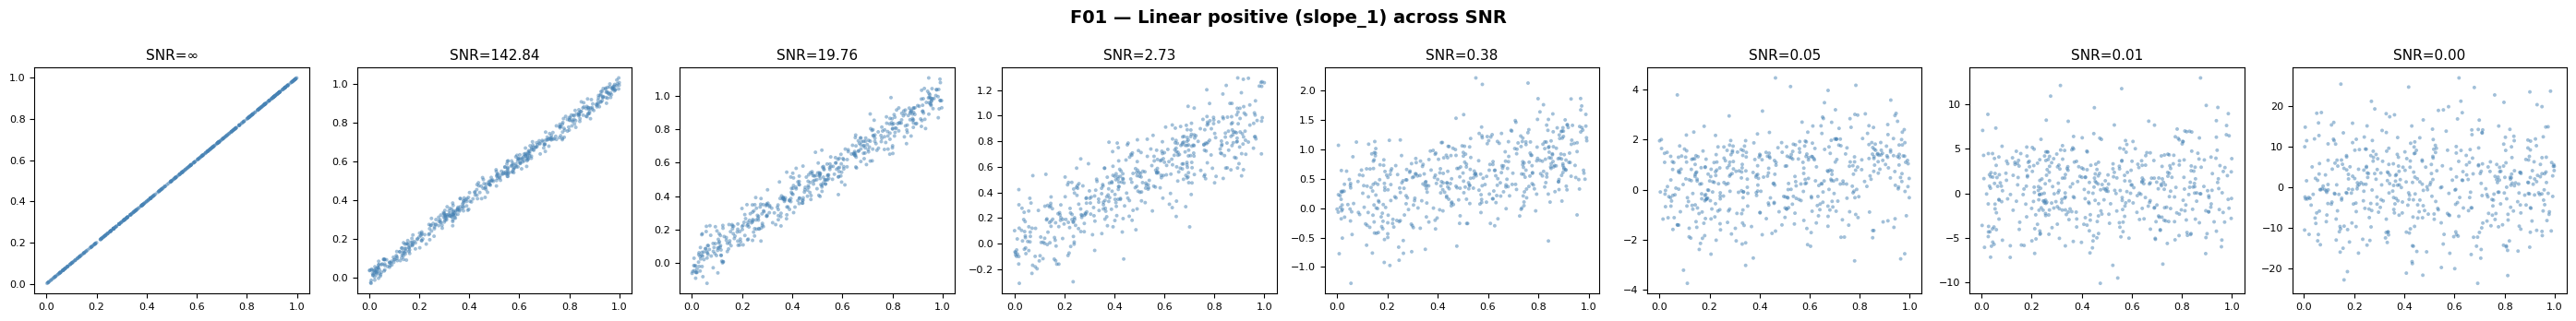

In [34]:
# Spot-check: reproducibility
test_idx = 100
test_cid = int(cases_df.iloc[test_idx]['case_id'])
x_t, y_t = generate_scatter_xy(test_cid)
assert np.allclose(x_all[test_idx], x_t), 'Reproducibility failed'
assert np.allclose(y_all[test_idx], y_t), 'Reproducibility failed'
print('Reproducibility check passed')

# Sample visualization: F01 standard across SNR levels
std_configs = [c for c in shape_configs if c.family_id == 'F01' and c.variant_level == 'standard']
sample_cfg = std_configs[0]
fam_cases = cases_df[(cases_df['shape_config_id'] == sample_cfg.shape_config_id) &
                     (cases_df['replicate'] == 0)]
snr_picks = [SNR_GRID[-1]] + [SNR_GRID[i] for i in [180, 150, 120, 90, 60, 30, 0]]

fig, axes = plt.subplots(1, len(snr_picks), figsize=(3.5 * len(snr_picks), 3.5))
fig.suptitle(f'{sample_cfg.family_id} — {sample_cfg.labels["family_name"]} ({sample_cfg.variant_name}) across SNR',
             fontsize=14, fontweight='bold')

for ax, snr_val in zip(axes, snr_picks):
    snr_str = 'inf' if math.isinf(snr_val) else float(snr_val)
    match = fam_cases[fam_cases['snr'] == snr_str]
    if len(match) == 0:
        ax.set_title(f'SNR={snr_str}\n(not found)', fontsize=10)
        continue
    idx = match.index[0]
    ax.scatter(x_all[idx], y_all[idx], s=8, alpha=0.5, color='steelblue', edgecolors='none')
    ax.set_title(f'SNR={"∞" if math.isinf(snr_val) else f"{snr_val:.2f}"}', fontsize=11)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

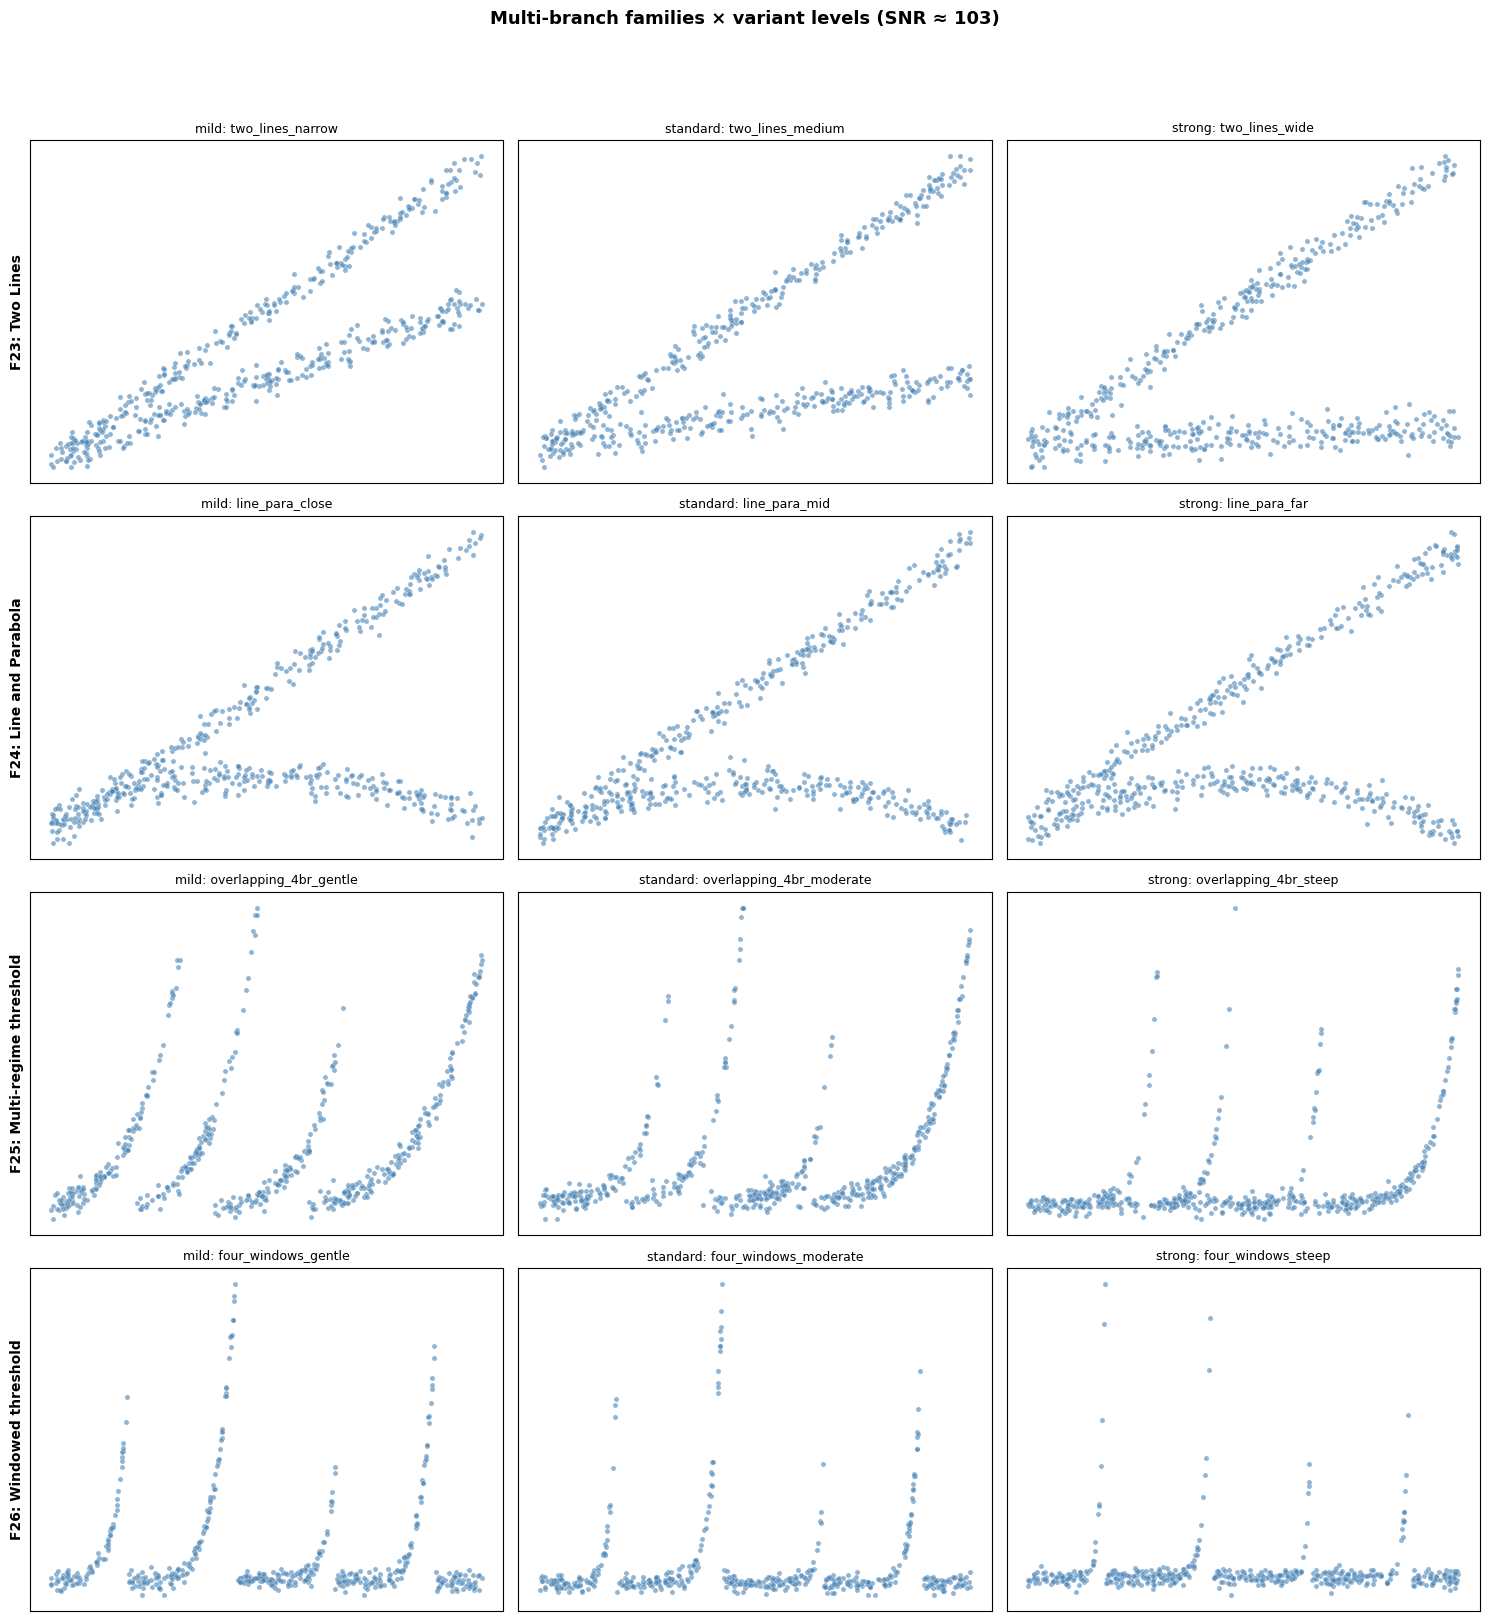

In [35]:
# ── Preview multi-branch families (F23-F26) × variant levels ──

preview_snr = 100.0
closest_snr = min(
    [s for s in SNR_GRID if not math.isinf(s)],
    key=lambda s: abs(s - preview_snr),
)

preview_families = ['F23', 'F24', 'F25', 'F26']
variant_levels_preview = ['mild', 'standard', 'strong']

fig, axes = plt.subplots(len(preview_families), 3, figsize=(15, len(preview_families) * 4))
fig.suptitle(f'Multi-branch families × variant levels (SNR ≈ {closest_snr:.0f})',
             fontsize=13, fontweight='bold', y=1.01)

for row, fam_id in enumerate(preview_families):
    for col, vlevel in enumerate(variant_levels_preview):
        ax = axes[row, col]
        match = cases_df[(cases_df['family_id'] == fam_id) &
                         (cases_df['variant_level'] == vlevel) &
                         (cases_df['snr'] == closest_snr) &
                         (cases_df['replicate'] == 0)]
        if len(match) > 0:
            idx = match.index[0]
            ax.scatter(x_all[idx], y_all[idx], s=14, alpha=0.6,
                       color='steelblue', edgecolors='white', linewidths=0.3)
            ax.set_title(f'{vlevel}: {match.iloc[0]["variant_name"]}', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f'{fam_id}: {FAMILY_LABELS[fam_id]["family_name"]}',
                          fontsize=10, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

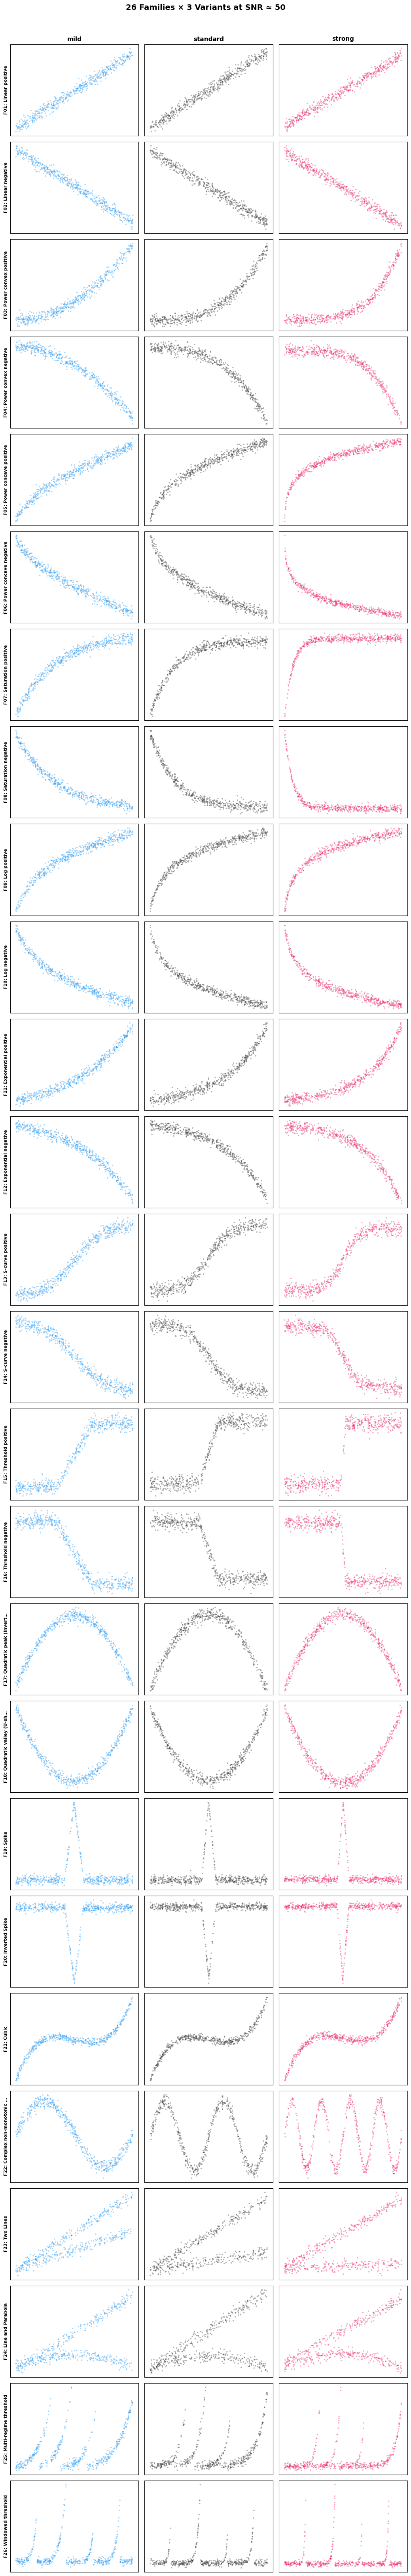

In [36]:
# ── Overview: all families × 3 variant levels at SNR ≈ 50 ──

overview_snr = 50.0
closest_overview_snr = min(
    [s for s in SNR_GRID if not math.isinf(s)],
    key=lambda s: abs(s - overview_snr),
)

all_family_ids = [f'F{i:02d}' for i in range(1, 27)]
variant_levels = ['mild', 'standard', 'strong']
variant_colors = {'mild': '#2196F3', 'standard': '#333333', 'strong': '#E91E63'}

n_rows = len(all_family_ids)
n_cols = len(variant_levels)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 2.5 * n_rows))
fig.suptitle(f'26 Families × 3 Variants at SNR ≈ {closest_overview_snr:.0f}',
             fontsize=14, fontweight='bold', y=1.0)

for row, fam_id in enumerate(all_family_ids):
    for col, vlevel in enumerate(variant_levels):
        ax = axes[row, col]
        match = cases_df[(cases_df['family_id'] == fam_id) &
                         (cases_df['variant_level'] == vlevel) &
                         (cases_df['snr'] == closest_overview_snr) &
                         (cases_df['replicate'] == 0)]
        if len(match) > 0:
            idx = match.index[0]
            ax.scatter(x_all[idx], y_all[idx], s=6, alpha=0.4,
                       color=variant_colors[vlevel], edgecolors='none')
            vname = match.iloc[0]['variant_name']
        else:
            vname = '—'

        if row == 0:
            ax.set_title(vlevel, fontsize=11, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

        if col == 0:
            short = FAMILY_LABELS[fam_id]['family_name']
            if len(short) > 25:
                short = short[:22] + '…'
            ax.set_ylabel(f'{fam_id}: {short}', fontsize=8, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()